# Poisson equation with periodic boundary conditions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
u(x=0,y)=u(x=L_x,y) \\
u_{\text{D}}(x,y=0)=u_{\text{D}}(x,y=L_y)=0~\text{or}~u(x,y=0)=u(x,y=L_y) \\
f(x, y) =\cos\left(\frac{2\pi x}{L_x}\right)\cos\left(\frac{2\pi y}{L_y}\right)
\end{cases}
$$

In [ ]:
import numpy as np
from dolfinx.fem import FunctionSpace
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, cross_section_grid
from lucifex.solver import bvp, BoundaryConditions
from lucifex.plt import plot_colormap, plot_line, save_figure
from lucifex.pde.poisson import poisson


Lx = 2.0
Ly = 1.0
mesh = rectangle_mesh(Lx, Ly, 64, 64)
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)
fs = FunctionSpace(mesh, ('P', 1))

def right_to_left(x: np.ndarray) -> np.ndarray:
    return np.vstack((x[0] - Lx, x[1]))

def upper_to_lower(x: np.ndarray) -> np.ndarray:
    return np.vstack((x[0], x[1] - Ly))

solutions = {}
ybc_opts = (
    ('dirichlet', boundary['lower', 'upper'], 0.0),
    ('periodic', boundary['upper'], upper_to_lower),
)
for ybc in ybc_opts:
    bcs = BoundaryConditions(
        ('periodic', boundary['right'], right_to_left),
        ybc,
    )
    f = Function(fs, lambda x: np.cos(2 * np.pi * x[0] / Lx) * np.cos(2 * np.pi * x[1] / Ly), name='f')
    u = Function(fs, name='u')
    u_solver = bvp(poisson, bcs)(u, f)
    u_solver.solve()
    solutions[ybc[0]] = u

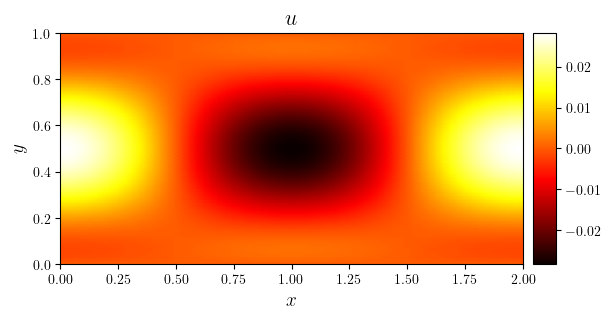

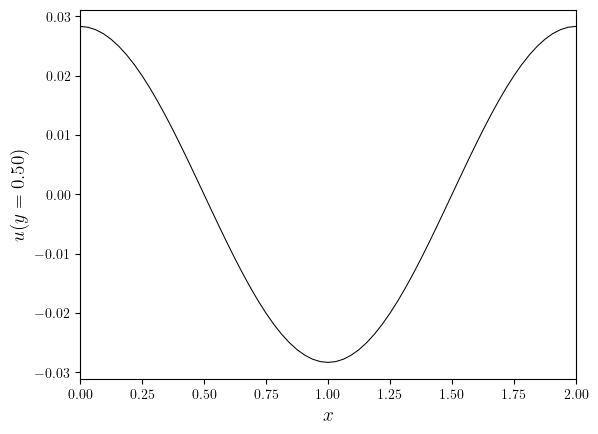

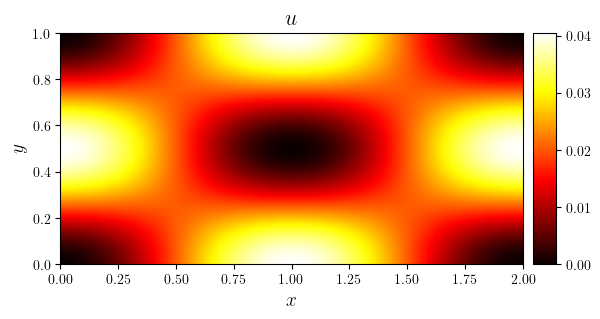

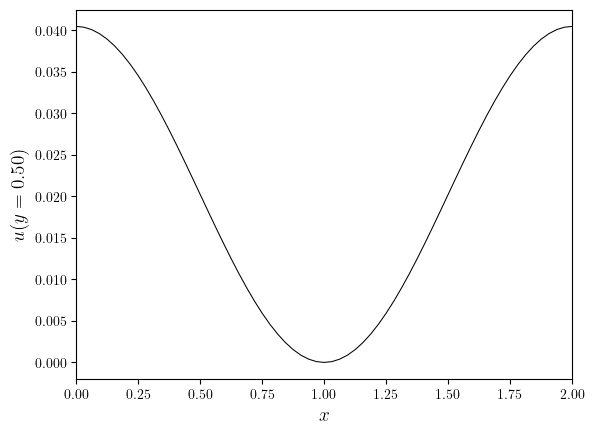

In [ ]:
for ybc, u in solutions.items():
    fig, ax = plot_colormap(u, title=f'${u.name}$')
    save_figure(f'u(x,y)_{ybc}', thumbnail=(ybc == 'periodic'))(fig)
    ux, y_value = cross_section_grid(u, 'y', 0.5)
    fig, ax = plot_line(ux, x_label='$x$', y_label=f'${u.name}(y={y_value:.2f})$')
    save_figure(f'u(x,y={y_value:.2f})_{ybc}')(fig)